In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

In [36]:
df = pd.read_csv("scrap price.csv")

In [37]:
df.head(-25)

,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,176,-1,toyota corona,gas,std,four,hatchback,fwd,front,102.4,...,122,mpfi,3.31,3.54,8.7,92,4200,27,32,9988.0
176,177,-1,toyota corolla,gas,std,four,sedan,fwd,front,102.4,...,122,mpfi,3.31,3.54,8.7,92,4200,27,32,10898.0
177,178,-1,toyota mark ii,gas,std,four,hatchback,fwd,front,102.4,...,122,mpfi,3.31,3.54,8.7,92,4200,27,32,11248.0
178,179,3,toyota corolla liftback,gas,std,two,hatchback,rwd,front,102.9,...,171,mpfi,3.27,3.35,9.3,161,5200,20,24,16558.0


In [38]:
df.shape

(205, 26)

In [39]:
X = df[["enginesize","horsepower","wheelbase"]]
y=df["price"]

In [40]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42)

In [41]:
lr = LinearRegression()

In [42]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
y_pred = lr.predict(X_test)
print(y_pred)

[27495.03029751 17833.91257456 11734.95541817 13192.51895813
 22256.78045161  6986.20909487  7503.68178465  7416.7962217
 10368.62594205  6371.58793913 14860.66529867  7150.86711873
 16952.45708177 12708.05110197 40604.68356911  6283.53956139
   796.52784149 18246.40551846 11065.62779417 10412.94745921
 11329.02972434 22052.31359638  7119.17364636  3976.29349617
  6092.24241077 27495.03029751 15773.41333125 16475.57074402
  6986.20909487 16475.57074402 22256.78045161  6092.24241077
  6283.53956139 21936.4928162   9143.39201486 21525.47541843
 11603.74833806  7004.32977619  6414.8369966  18246.40551846
  9496.77483898]


In [44]:
r2 = r2_score(y_test,y_pred)
print(r2)

0.8232695311904854


In [ ]:
mean_squared_error(y_test, y_pred)

13951813.819770008

In [48]:
pd.Series(lr.coef_, index=X.columns)

enginesize     92.003765
horsepower     72.654259
wheelbase     221.607586
dtype: float64

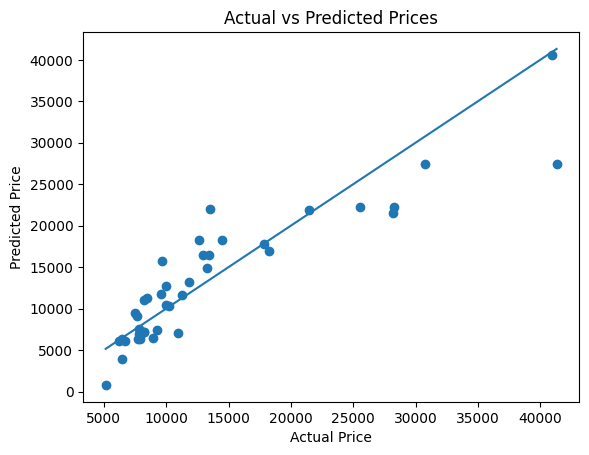

In [49]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()
